In [ ]:
pip install sentence-transformers scikit-learn matplotlib numpy

Embedding shape: (10, 384)


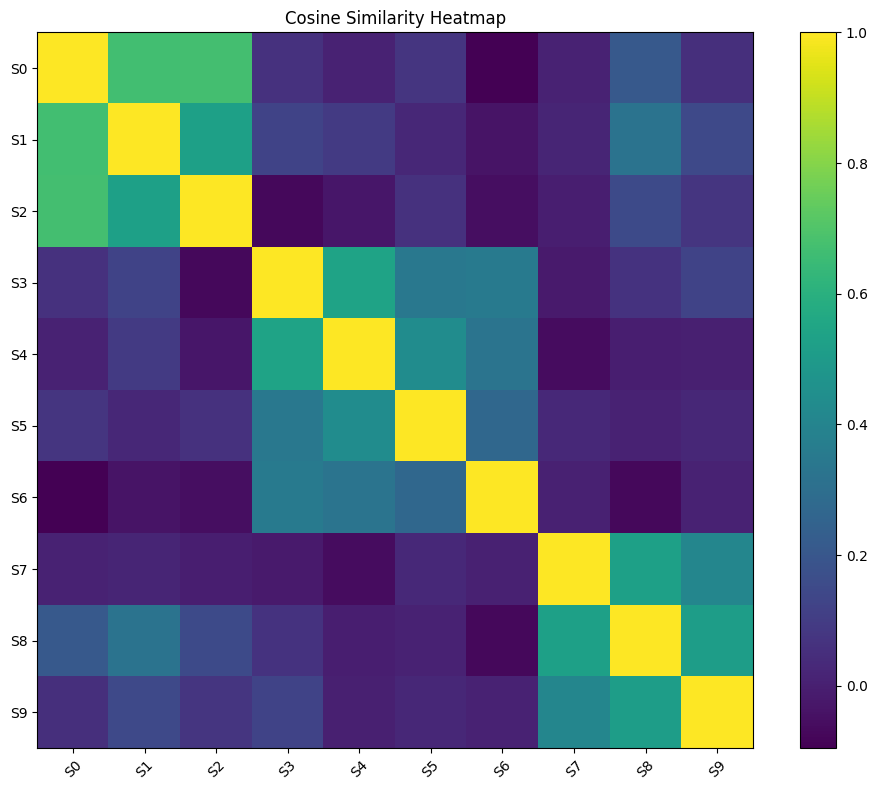


Query: The bowler took three wickets in one over

Top 2 most similar sentences:
- India dominates the sport of Cricket (Score: 0.4707)
- Cricket is played on a pitch of 22 yards (Score: 0.4506)


In [3]:
# semantic_similarity.py

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np


def load_model(model_name="all-MiniLM-L6-v2"):
    """Load pre-trained sentence transformer model"""
    return SentenceTransformer(model_name)


def get_sample_sentences():
    """Return sample sentences"""
    return [
        "Cricket is played across 20 countries in the world",
        "India dominates the sport of Cricket",
        "Cricket is played on a pitch of 22 yards",
        "Cooking is one of the hardest jobs in the world",
        "Women love cooking for their families",
        "Proper kitchen setup should be provided for cooking in restaurants",
        "Early man started cooking with the discovery of fire",
        "Cybersecurity is becoming increasingly important for personal identifiable information",
        "Cybersecurity crimes are increasing in India",
        "Poor cybersecurity strategy makes a company vulnerable to cyber attacks"
    ]


def generate_embeddings(model, sentences):
    """Generate embeddings for sentences"""
    return model.encode(sentences)


def plot_heatmap(similarity_matrix, sentences):
    """Plot cosine similarity heatmap"""
    plt.figure(figsize=(10, 8))
    plt.imshow(similarity_matrix)
    plt.colorbar()

    labels = [f"S{i}" for i in range(len(sentences))]
    plt.xticks(ticks=range(len(sentences)), labels=labels, rotation=45)
    plt.yticks(ticks=range(len(sentences)), labels=labels)

    plt.title("Cosine Similarity Heatmap")
    plt.tight_layout()
    plt.show()


def find_top_matches(model, query, sentences, vectors, top_k=2):
    """Find top K similar sentences"""
    query_vector = model.encode([query])
    similarities = cosine_similarity(query_vector, vectors)[0]

    top_indices = np.argsort(similarities)[-top_k:][::-1]

    print(f"\nQuery: {query}\n")
    print(f"Top {top_k} most similar sentences:")

    for idx in top_indices:
        print(f"- {sentences[idx]} (Score: {similarities[idx]:.4f})")


def main():
    # Load model
    model = load_model()

    # Get sentences
    sentences = get_sample_sentences()

    # Generate embeddings
    vectors = generate_embeddings(model, sentences)
    print(f"Embedding shape: {vectors.shape}")

    # Compute similarity matrix
    similarity_matrix = cosine_similarity(vectors)

    # Plot heatmap
    plot_heatmap(similarity_matrix, sentences)

    # Query example
    query = "The bowler took three wickets in one over"
    find_top_matches(model, query, sentences, vectors)


if __name__ == "__main__":
    main()